In [1]:
import numpy as np

import matplotlib.pyplot as plt                 # Manipular gráficas
from IPython.display import Image, display      # Mostrar animaciones

from EcuacionCalor import (
    primitiva_rect,
    FDM_HeatModel,
    generar_DIR, generar_ROB, generar_NEU,
    fdm2d, fdm2d_graph_mesh,
    GraphType
)

GUIA DE TRABAJOS PRACTICOS Nº 2
---

# MÉTODO DE DIFERENCIAS FINITAS 2D

## Ejercicio 1

Dada la siguiente ecuación diferencial en dos dimensiones que modela la transferencia de calor en
una placa:

$$
\rho c_p \frac{\partial T}{\partial t}
= k \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) - c ~T + G, \quad \forall ~x \in [x_1,x_2], \forall ~y \in [y_1,y_2]
$$

Resuelva los problemas propuestos en la siguiente tabla, donde se describen los valores de las
constantes del modelo y las condiciones de borde. Consideraciones a tener en cuenta:

* Analice los órdenes de aproximación al utilizar aproximaciones de 1er y 2do orden para las condiciones de borde.
* Analice los órdenes de aproximación al utilizar mallas uniformes y no uniformes.
* Implemente los siguientes esquemas temporales: Forward Euler, Backward Euler. Considerar siempre la condición inicial nula: $T(x,0)=0$.

### Ítem (a)

<table>
    <thead>
        <tr>
            <th rowspan="1"></th>
            <th colspan="2">Extremos</th>
            <th colspan="4">Condiciones de borde</th>
            <th colspan="4">Constantes del modelo</th>
        </tr>
        <tr>
            <th>Ítem</th>
            <th>Inferior<br>Izquierda</th>
            <th>Superior<br>Derecha</th>
            <th>($x_1 < x < x_2, y_1$)</th>
            <th>($x_1 < x < x_2, y_2$)</th>
            <th>($x_1, y_1 < y < y_2$)</th>
            <th>($x_2, y_1 < y < y_2$)</th>
            <th>$\rho c_p$</th>
            <th>k</th>
            <th>c</th>
            <th>G</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>a</td>
            <td>(0, 0)</td>
            <td>(1, 1)</td>
            <td>T=20</td>
            <td>T=20</td>
            <td>T=20</td>
            <td>T=20</td>
            <td>0</td>
            <td>2</td>
            <td>0</td>
            <td>300</td>
        </tr>
    </tbody>
</table>

In [2]:
xnode, icone, vert, bounds = primitiva_rect(x_subdiv=2, y_subdiv=2, plot=False)

In [3]:
nnoodes = len(xnode)

# Modelo inciso (a)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.full(nnoodes, 2.0),
    c = np.zeros(nnoodes),
    G = np.full(nnoodes, 300.0),
    rho = 0.0,
    cp = 0.0,
    ts = -1,    # Estacionario
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F0 = generar_DIR(bounds[0], xnode, f_constante(20))     # T = 20
DIR_F1 = generar_DIR(bounds[1], xnode, f_constante(20))

DIR_F2 = generar_DIR(bounds[2], xnode, f_constante(20))
DIR_F3 = generar_DIR(bounds[3], xnode, f_constante(20))

DIR = np.vstack((
    DIR_F0,
    DIR_F1,
    DIR_F2,
    DIR_F3,
))

PHI, Q = fdm2d(xnode, icone, DIR, None, None, model)

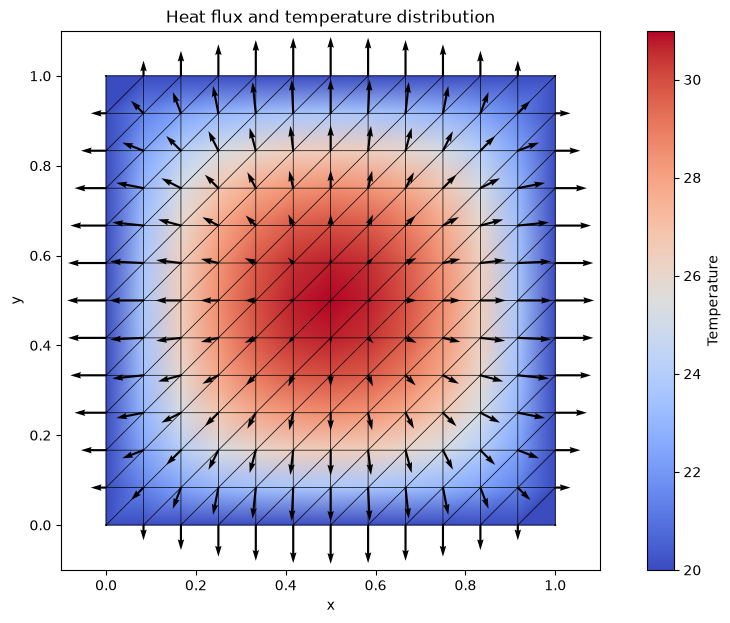

In [4]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.1);

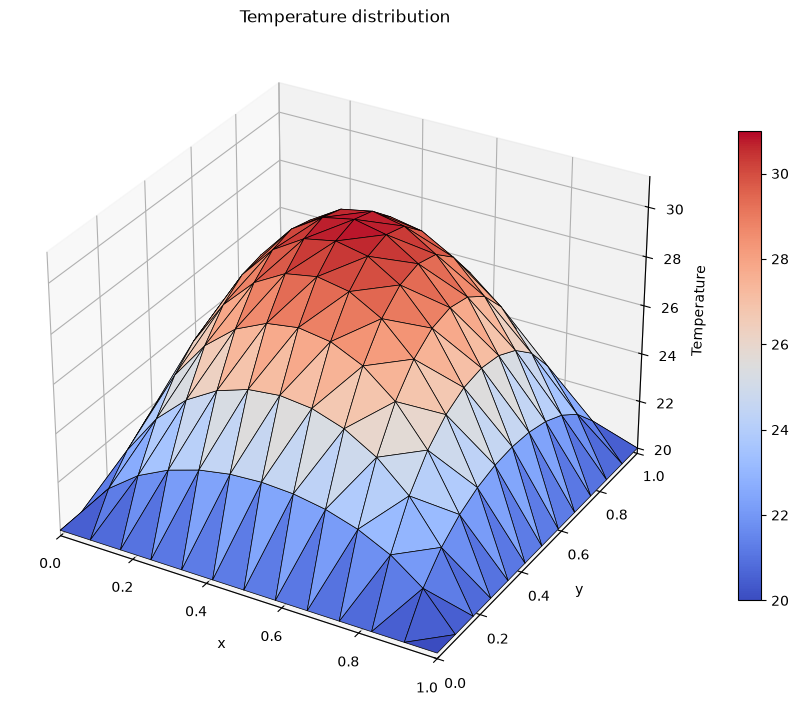

In [5]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0);

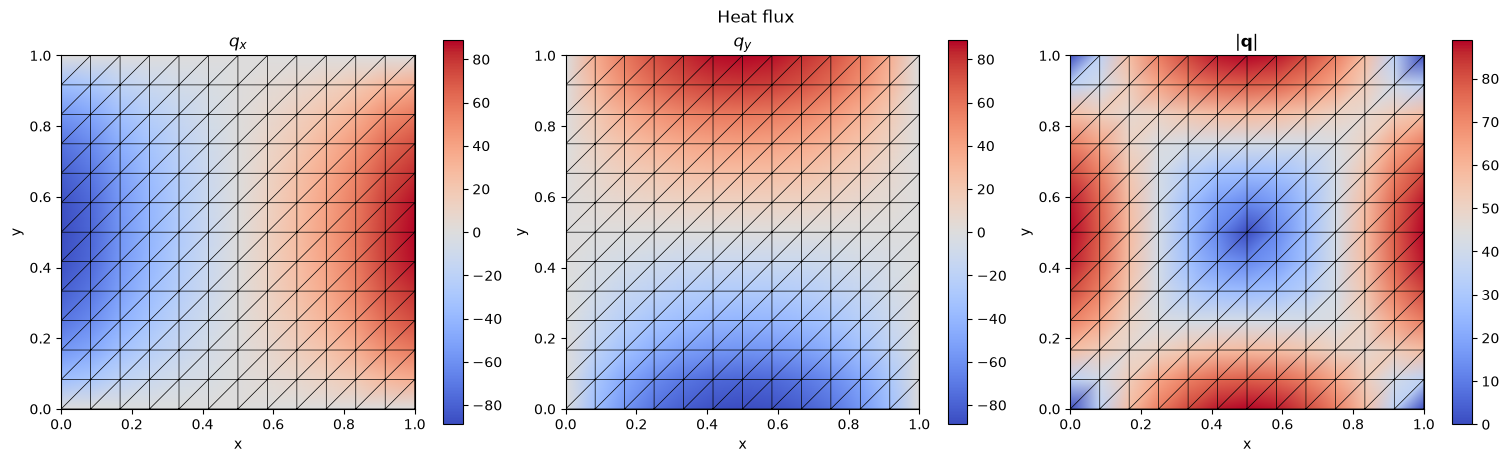

In [6]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX_COMPONENTS, mesh=True, margin=0);

### Ítem (b)

<table>
    <thead>
        <tr>
            <th rowspan="1"></th>
            <th colspan="2">Extremos</th>
            <th colspan="4">Condiciones de borde</th>
            <th colspan="4">Constantes del modelo</th>
        </tr>
        <tr>
            <th>Ítem</th>
            <th>Inferior<br>Izquierda</th>
            <th>Superior<br>Derecha</th>
            <th>($x_1 < x < x_2, y_1$)</th>
            <th>($x_1 < x < x_2, y_2$)</th>
            <th>($x_1, y_1 < y < y_2$)</th>
            <th>($x_2, y_1 < y < y_2$)</th>
            <th>$\rho c_p$</th>
            <th>k</th>
            <th>c</th>
            <th>G</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>b</td>
            <td>(0, 0)</td>
            <td>(1, 2)</td>
            <td>T=20</td>
            <td>T=0</td>
            <td>T=20</td>
            <td>T=0</td>
            <td>0</td>
            <td>1</td>
            <td>4</td>
            <td>300</td>
        </tr>
    </tbody>
</table>

In [ ]:
xnode, icone, vert, bounds = primitiva_rect(y_scale=2.0, x_subdiv=2, y_subdiv=2, plot=True)

Condiciones de contorno según el orden de `bounds`:

$F0 ~\{x_1 \leq x \leq x_2, y_1\} : ~T = 20$

$F1 ~\{x_2, y_1 \leq y \leq y_2\} : ~T = 0$

$F2 ~\{x_1 \leq x \leq x_2, y_2\} : ~T = 0$

$F3 ~\{x_1, y_1 \leq y \leq y_2\} : ~T = 20$

In [8]:
nnoodes = len(xnode)

# Modelo inciso (b)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.full(nnoodes, 4.0),
    G = np.full(nnoodes, 300.0),
    rho = 0.0,
    cp = 0.0,
    ts = -1,    # Estacionario
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F0 = generar_DIR(bounds[0], xnode, f_constante(20))
DIR_F1 = generar_DIR(bounds[1], xnode, f_constante(0))

DIR_F2 = generar_DIR(bounds[2], xnode, f_constante(0))
DIR_F3 = generar_DIR(bounds[3], xnode, f_constante(20))

DIR = np.vstack((
    DIR_F0,
    DIR_F1,
    DIR_F2,
    DIR_F3,
))

PHI, Q = fdm2d(xnode, icone, DIR, None, None, model)

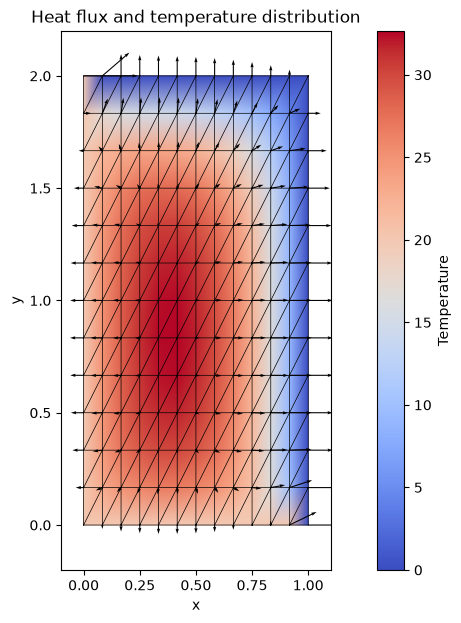

In [9]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.1);

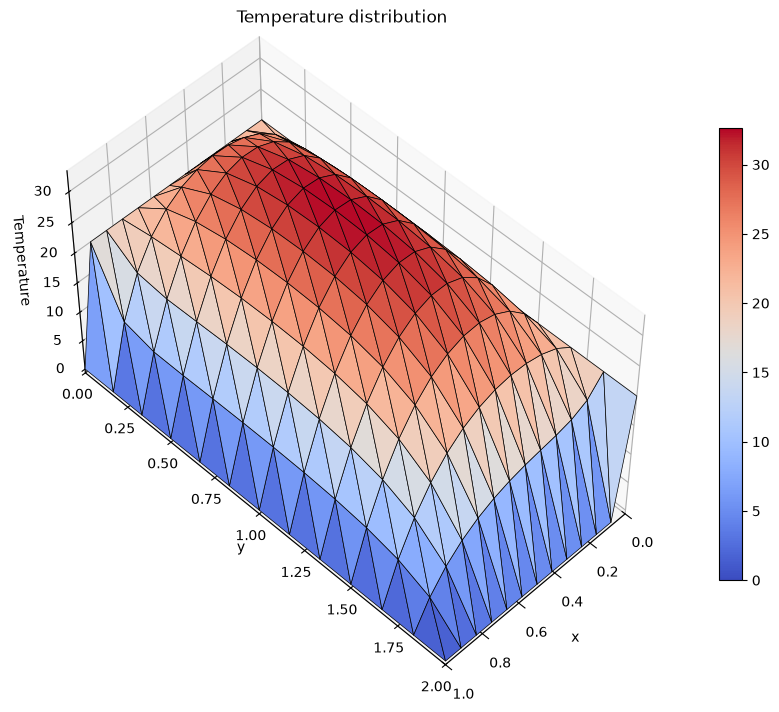

In [10]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=45, elev=50);

### Ítem (c)

<table>
    <thead>
        <tr>
            <th rowspan="1"></th>
            <th colspan="2">Extremos</th>
            <th colspan="4">Condiciones de borde</th>
            <th colspan="4">Constantes del modelo</th>
        </tr>
        <tr>
            <th>Ítem</th>
            <th>Inferior<br>Izquierda</th>
            <th>Superior<br>Derecha</th>
            <th>($x_1 < x < x_2, y_1$)</th>
            <th>($x_1 < x < x_2, y_2$)</th>
            <th>($x_1, y_1 < y < y_2$)</th>
            <th>($x_2, y_1 < y < y_2$)</th>
            <th>$\rho c_p$</th>
            <th>k</th>
            <th>c</th>
            <th>G</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>c</td>
            <td>(0, 0)</td>
            <td>(4, 3)</td>
            <td>q=0</td>
            <td>T=50</td>
            <td>T=50</td>
            <td>q=0</td>
            <td>0</td>
            <td>1</td>
            <td>0</td>
            <td>$2x^2 + 3y^3$</td>
        </tr>
    </tbody>
</table>

In [ ]:
xnode, icone, vert, bounds = primitiva_rect(x_scale=4.0, y_scale=3.0, x_subdiv=2, y_subdiv=2, plot=True)

Condiciones de contorno según el orden de `bounds`:

$F0 ~\{x_1 \leq x \leq x_2, y_1\} : ~q = 0$ / Normal al sur: 1

$F1 ~\{x_2, y_1 \leq y \leq y_2\} : ~q = 0$ / Normal al este: 2

$F2 ~\{x_1 \leq x \leq x_2, y_2\} : ~T = 50$

$F3 ~\{x_1, y_1 \leq y \leq y_2\} : ~T = 50$

In [12]:
nnoodes = len(xnode)

# Fuente
G = 2.0 * np.pow(xnode[:,0], 2) + 3.0 * np.pow(xnode[:,1], 3)

# Modelo inciso (c)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.zeros(nnoodes),
    G = G,
    rho = 0.0,
    cp = 0.0,
    ts = -1,    # Estacionario
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F2 = generar_DIR(bounds[2], xnode, f_constante(50))
DIR_F3 = generar_DIR(bounds[3], xnode, f_constante(50))

DIR = np.vstack((
    DIR_F2,
    DIR_F3,
))

# Condiciones de contorno Neumann
NEU_F0 = generar_NEU(bounds[0], xnode, f_constante(0), 1)
NEU_F1 = generar_NEU(bounds[1], xnode, f_constante(0), 2)

NEU = np.vstack((
    NEU_F0,
    NEU_F1,
))

PHI, Q = fdm2d(xnode, icone, DIR, NEU, None, model)

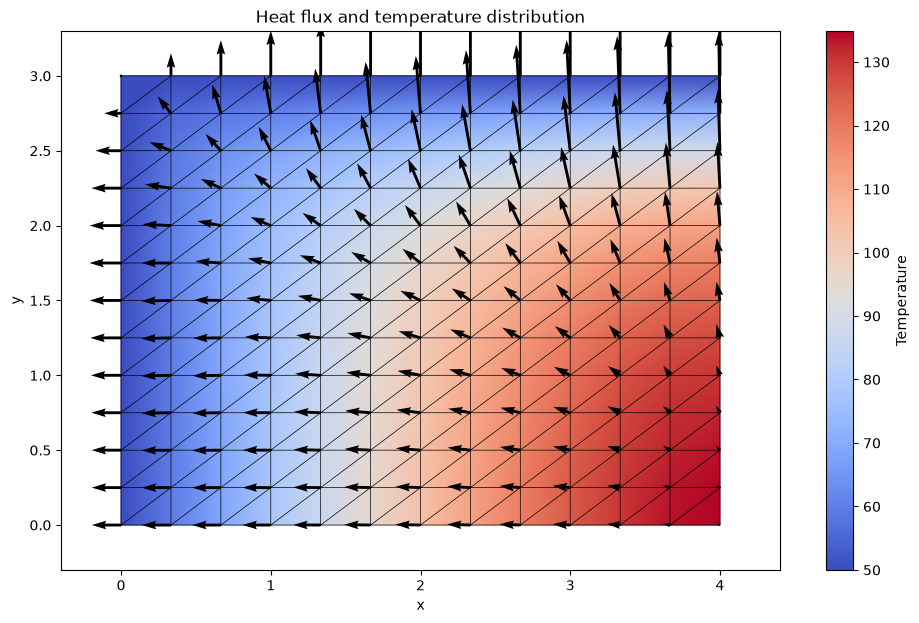

In [13]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.1);

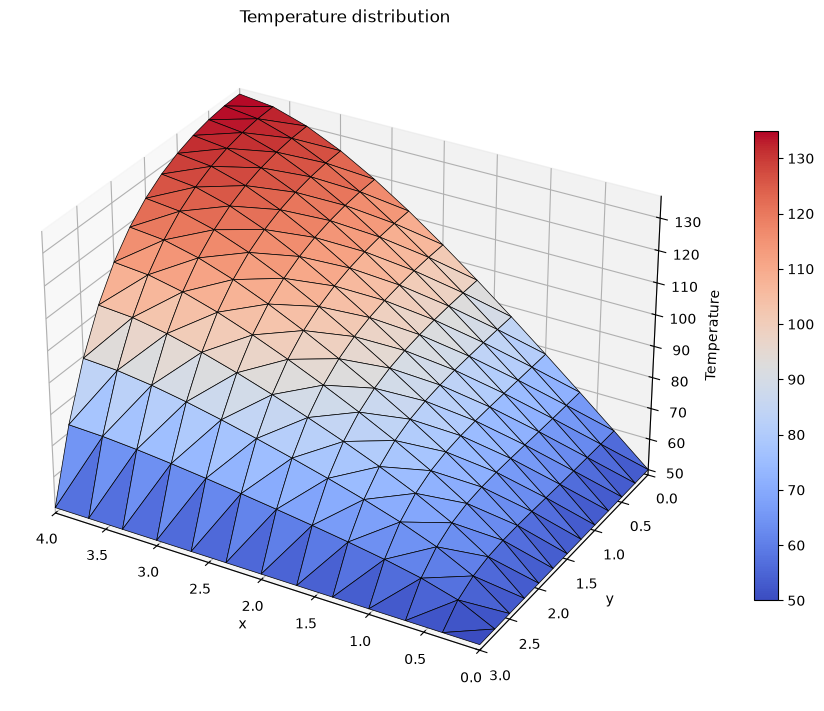

In [14]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=120);

### Ítem (d)

<table>
    <thead>
        <tr>
            <th rowspan="1"></th>
            <th colspan="2">Extremos</th>
            <th colspan="4">Condiciones de borde</th>
            <th colspan="4">Constantes del modelo</th>
        </tr>
        <tr>
            <th>Ítem</th>
            <th>Inferior<br>Izquierda</th>
            <th>Superior<br>Derecha</th>
            <th>($x_1 < x < x_2, y_1$)</th>
            <th>($x_1 < x < x_2, y_2$)</th>
            <th>($x_1, y_1 < y < y_2$)</th>
            <th>($x_2, y_1 < y < y_2$)</th>
            <th>$\rho c_p$</th>
            <th>k</th>
            <th>c</th>
            <th>G</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>d</td>
            <td>(1, 1)</td>
            <td>(3, 3)</td>
            <td>T=25</td>
            <td>h=2, $\phi_\infty$=50</td>
            <td>q=0</td>
            <td>q=10</td>
            <td>0</td>
            <td>1</td>
            <td>4</td>
            <td>0</td>
        </tr>
    </tbody>
</table>

In [ ]:
xnode, icone, vert, bounds = primitiva_rect(x_pos=1.0, y_pos=1.0, x_scale=2.0, y_scale=2.0, x_subdiv=2, y_subdiv=2, plot=True)

Condiciones de contorno según el orden de `bounds`:

$F0 ~\{x_1 \leq x \leq x_2, y_1\} : ~T = 25$

$F1 ~\{x_2, y_1 \leq y \leq y_2\} : ~q = 10$ / Normal al este: 2

$F2 ~\{x_1 \leq x \leq x_2, y_2\} : ~h = 2, ~\phi_\infty = 50$ / Normal al norte: 3

$F3 ~\{x_1, y_1 \leq y \leq y_2\} : ~q = 0$ / Normal al oeste: 4

In [16]:
nnoodes = len(xnode)

# Modelo inciso (d)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.ones(nnoodes),
    c = np.full(nnoodes, 4.0),
    G = np.zeros(nnoodes),
    rho = 0.0,
    cp = 0.0,
    ts = -1,    # Estacionario
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F0 = generar_DIR(bounds[0], xnode, f_constante(25.0))
DIR = np.vstack((
    DIR_F0,
))

# Condiciones de contorno Neumann
NEU_F1 = generar_NEU(bounds[1], xnode, f_constante(10.0), 2)
NEU_F3 = generar_NEU(bounds[3], xnode, f_constante(0.0), 4)

NEU = np.vstack((
    NEU_F1,
    NEU_F3,
))

# Condiciones de contorno Robin
ROB_F2 = generar_ROB(bounds[2], xnode, f_constante(2.0), f_constante(50.0), 3)
ROB = np.vstack((
    ROB_F2,
))

PHI, Q = fdm2d(xnode, icone, DIR, NEU, ROB, model)

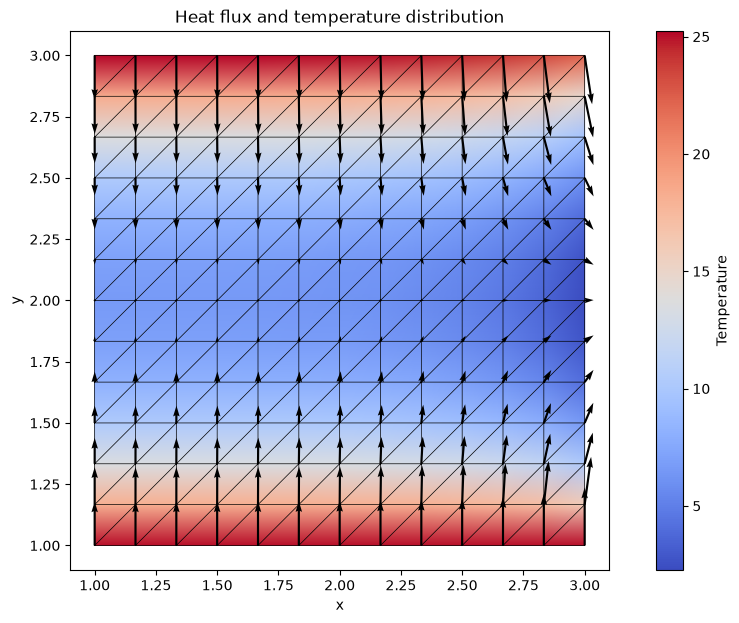

In [17]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.05);

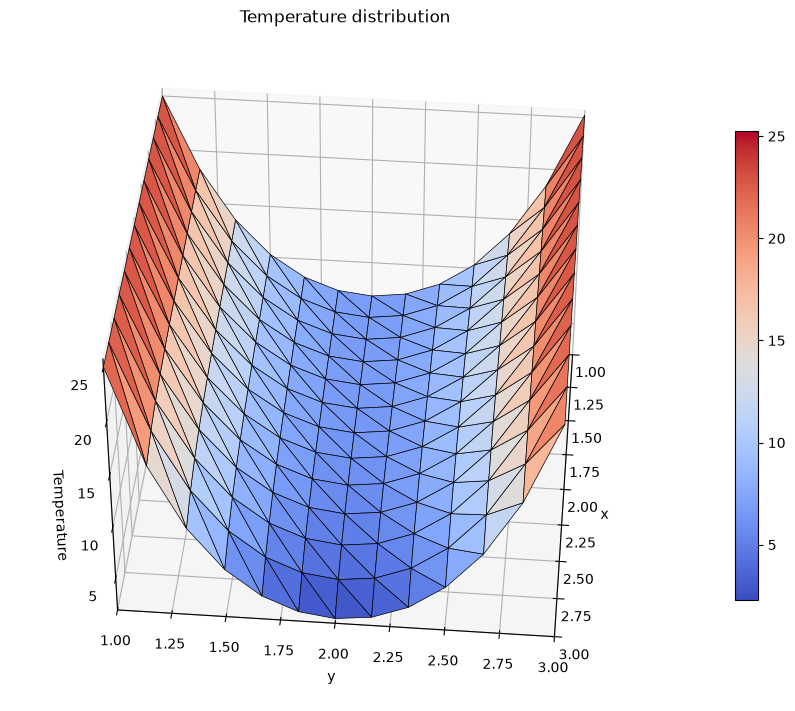

In [18]:
fdm2d_graph_mesh(xnode, icone, PHI, Q, graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=5, elev=40);